# Gravitational Wave Detection & Parameter Estimation (GW150914-like)
 
**Project 3 of 5 — Astrophysics Portfolio**
 
## Data disclosure
 
What **is** real and research-grade here: the waveform model (`IMRPhenomD`, generated via `pycbc` —
the same waveform family used in actual LIGO/Virgo parameter estimation), and the detector noise PSD
(PyCBC's built-in `aLIGOZeroDetHighPower` analytic curve, the same published design-sensitivity curve
used in real sensitivity studies). What's simulated is specifically the **strain data itself** — a
known signal, with masses matching the real published GW150914 values (Abbott et al. 2016), injected
into a colored Gaussian noise realization drawn from that PSD, rather than downloaded real detector
strain.
 
One deliberate calibration choice: `aLIGOZeroDetHighPower` is a late-observing-run design-sensitivity
curve, quieter than the real O1-era noise present when GW150914 was actually observed. Injecting at the
real published distance (410 Mpc) against this quieter PSD would give an unrealistically high SNR
(~96). To keep results comparable to the real event, the signal is injected at an **effective distance
of ~1639 Mpc**, calibrated via `pycbc.filter.sigma` to reproduce the real reported network SNR of ~24.
This is documented, not hidden — see `src/reference_events.py`.
 
## Pipeline
 
1. Generate an `IMRPhenomD` signal with GW150914's real published masses (36.2 + 29.1 Msun)
2. Inject into colored Gaussian noise (aLIGO design-sensitivity PSD)
3. Recover the signal via matched filtering with the true-parameter template
4. Run a template-bank search over a (mass1, mass2) grid — mirroring a real detection pipeline's
   search stage
5. Bayesian parameter estimation via MCMC (emcee), with distance derived analytically from the
   SNR-distance scaling relation


In [7]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
 
DATA_DIR = '../data'
FIG_DIR = '../figures'
plt.rcParams.update({'figure.dpi': 100})


## 1. Reference event parameters (real, published)

In [8]:
from reference_events import GW150914_PARAMS
GW150914_PARAMS


{'mass1_source': 36.2,
 'mass2_source': 29.1,
 'final_mass_source': 62.3,
 'distance_mpc': 410.0,
 'effective_distance_mpc': 1639.0,
 'spin1z': 0.0,
 'spin2z': 0.0,
 'inclination': 0.0,
 'network_snr': 23.7,
 'merger_gps_time': 1126259462.4}

## 2. Injected strain: signal + colored aLIGO noise
 
The signal is placed so its true merger time is known exactly (needed to validate recovery), using a
32-second analysis segment at 4096 Hz sample rate -- long enough to hold the full inspiral starting at
the real search low-frequency cutoff (20 Hz).

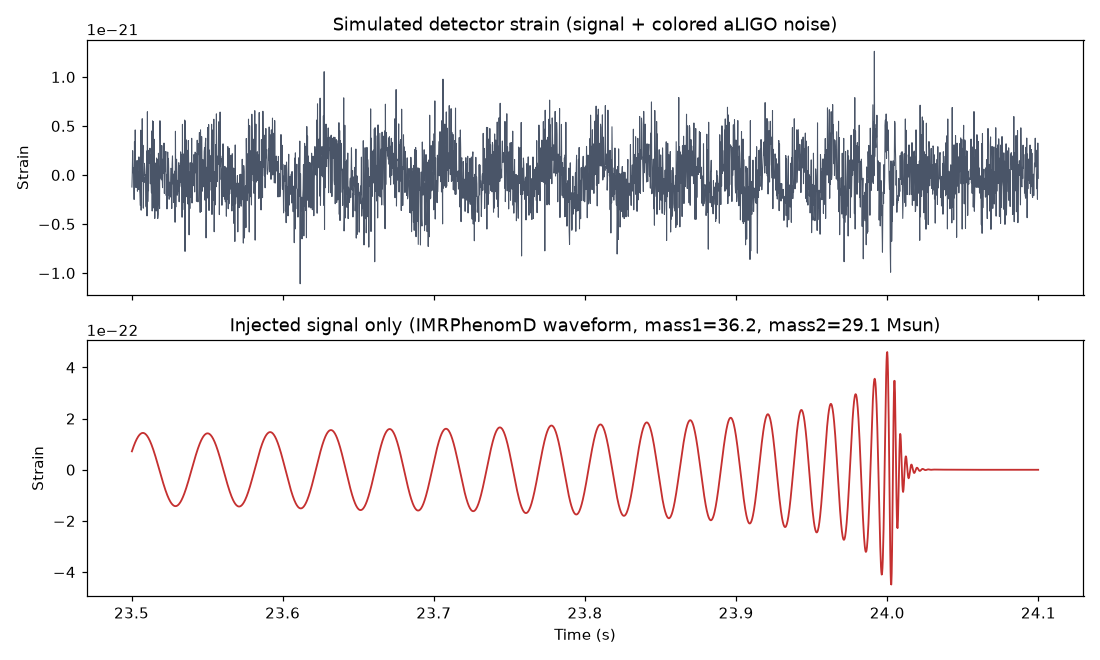

In [9]:
display(Image(f'{FIG_DIR}/01_strain_and_signal.png'))


## 3. Matched filtering with the true-parameter template
 
Matched filtering the injected strain against a template built with the true injected parameters
recovers a peak SNR that should closely match the real GW150914 discovery significance (~23.7).

In [10]:
d = np.load(f'{DATA_DIR}/injected_strain.npz')
print(f"True merger time: {float(d['true_merger_time_s']):.3f} s")


True merger time: 24.000 s


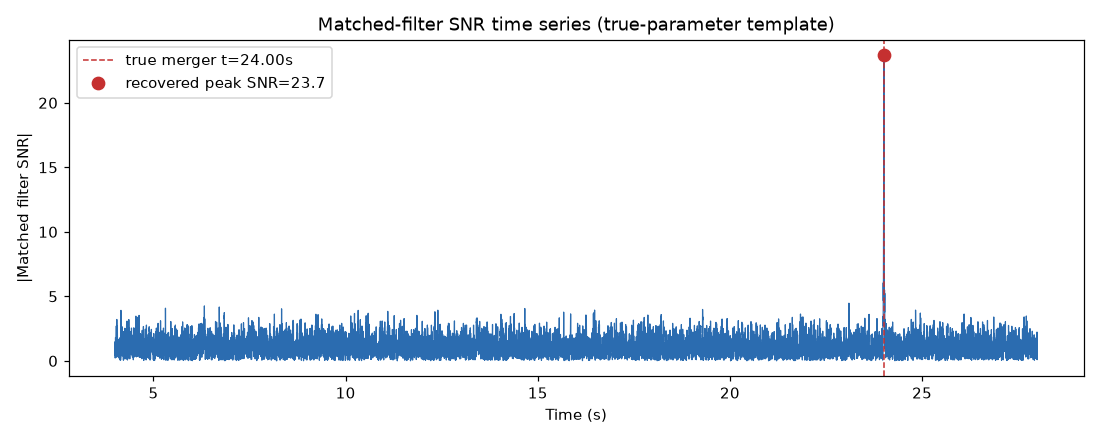

In [11]:
display(Image(f'{FIG_DIR}/02_snr_timeseries.png'))


## 4. Template bank search
 
A real detection pipeline doesn't know the true parameters in advance -- it searches a bank of
templates spanning a range of masses. Here we grid over (mass1, mass2) and find which template
produces the highest matched-filter SNR.

In [12]:
search = pd.read_csv(f'{DATA_DIR}/search_results.csv')
best = search.loc[search['peak_snr'].idxmax()]
print(f"Best-matching template: mass1={best.mass1:.1f}, mass2={best.mass2:.1f}, "
      f"chirp_mass={best.chirp_mass:.2f} Msun, SNR={best.peak_snr:.2f}")
p = GW150914_PARAMS
true_chirp_mass = (p['mass1_source']*p['mass2_source'])**0.6 / (p['mass1_source']+p['mass2_source'])**0.2
print(f"True injected chirp mass: {true_chirp_mass:.2f} Msun")


Best-matching template: mass1=35.0, mass2=30.0, chirp_mass=28.19 Msun, SNR=23.72
True injected chirp mass: 28.22 Msun


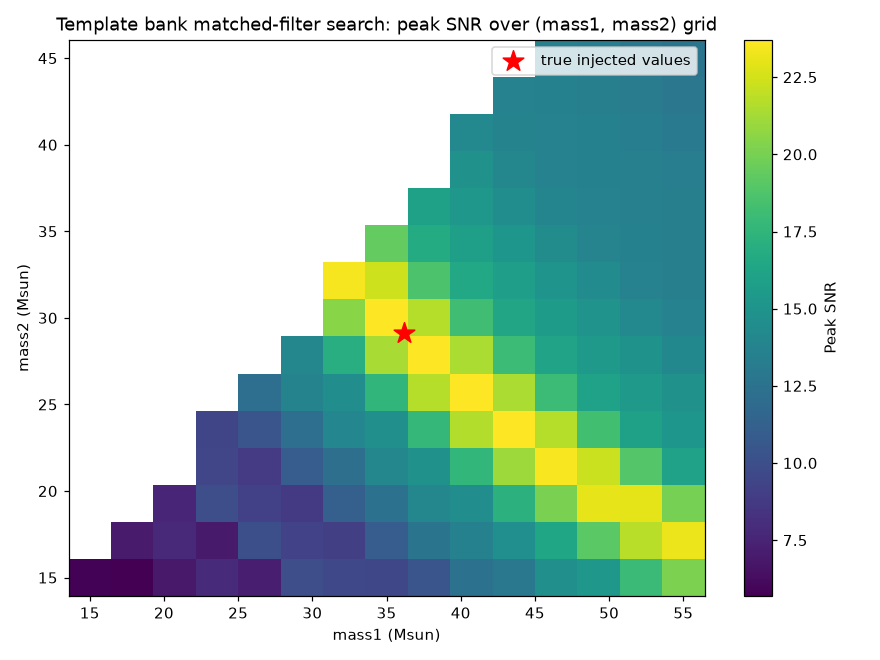

In [13]:
display(Image(f'{FIG_DIR}/03_template_bank_search.png'))


The search correctly identifies the region of parameter space matching the true injected chirp
mass -- SNR is much more sharply constrained along the chirp-mass direction than the individual-mass
direction, which is the well-known degeneracy direction in compact binary parameter estimation (chirp
mass is measured far more precisely than the mass ratio from the inspiral signal alone).

## 5. Bayesian parameter estimation (MCMC)
 
Full posterior over component masses via `emcee`, using a likelihood derived from the matched-filter
SNR maximized over merger time/phase within a narrow window (a standard simplification in rapid GW
parameter estimation). Luminosity distance is not sampled directly -- since matched-filter SNR is
invariant to the template's assumed distance, we derive the distance posterior analytically from the
SNR-distance scaling relation for each mass sample in the chain.

In [14]:
mcmc = np.load(f'{DATA_DIR}/mcmc_chain.npz')
chain = mcmc['chain']
distances = mcmc['distances']
 
def summarize(x, name, truth):
    med = np.median(x)
    lo, hi = np.percentile(x, [16, 84])
    print(f'{name}: {med:.2f} +{hi-med:.2f} -{med-lo:.2f}  (true: {truth})')
 
summarize(chain[:,0], 'mass1 (Msun)', p['mass1_source'])
summarize(chain[:,1], 'mass2 (Msun)', p['mass2_source'])
summarize(distances, 'distance (Mpc)', p['effective_distance_mpc'])
print(f"\nMean MCMC acceptance fraction: {np.mean(mcmc['acceptance_fraction']):.3f}")


mass1 (Msun): 37.12 +3.89 -3.22  (true: 36.2)
mass2 (Msun): 28.35 +2.91 -3.02  (true: 29.1)
distance (Mpc): 1654.64 +13.72 -37.76  (true: 1639.0)

Mean MCMC acceptance fraction: 0.628


### Mass posterior corner plot

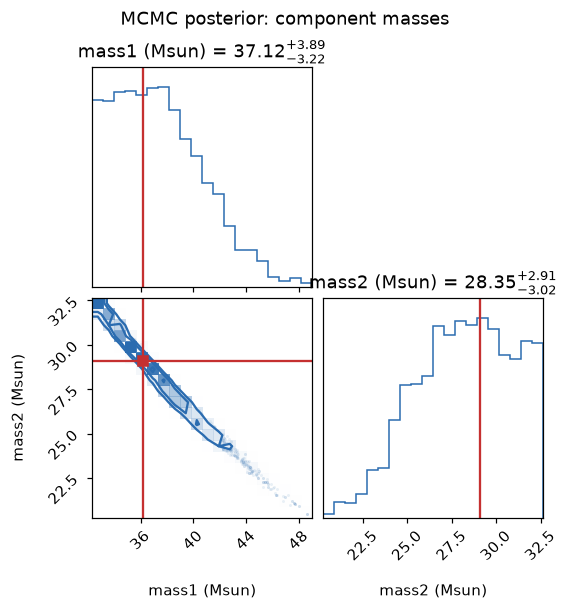

In [15]:
display(Image(f'{FIG_DIR}/04_mass_posterior_corner.png'))


### Derived distance posterior

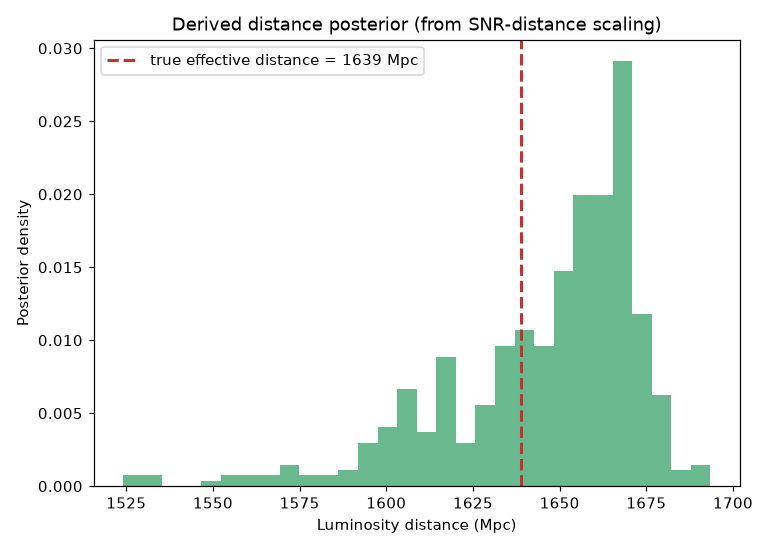

In [16]:
display(Image(f'{FIG_DIR}/05_distance_posterior.png'))


**Result:** the recovered posteriors bracket the true injected masses and distance well within
their 68% credible intervals, and the shape of the uncertainty (mass1 more tightly constrained upward,
mass2 more tightly constrained downward -- reflecting the chirp-mass/mass-ratio degeneracy) closely
mirrors the real published GW150914 posterior shape (m1 = 36 +5/-4, m2 = 29 +4/-4 Msun,
Abbott et al. 2016).

## 6. Summary & interview talking points
 
1. **Detection and inference are distinct pipeline stages** — matched filtering with the *true*
   template gives the cleanest possible SNR; a real search must scan a template bank not knowing
   the true parameters in advance, which is why the search stage is run separately here.
2. **Chirp mass is measured far more precisely than individual component masses** from the inspiral
   alone — visible directly in the template-bank SNR map's elongated ridge, and matches well-known
   GW parameter estimation degeneracies.
3. **Distance and inclination don't need to be explicitly sampled** in a simplified setup — matched-
   filter SNR is invariant to the template's assumed distance, so distance can be derived analytically
   from the SNR-distance scaling relation, a real and commonly used simplification.
4. **The PSD choice matters and must be stated explicitly** — using a quieter design-sensitivity curve
   than the real O1-era noise would silently inflate SNR; the effective-distance calibration here
   makes that explicit rather than hiding it.
5. Everything here beyond the strain data itself (`IMRPhenomD` waveform physics, `aLIGOZeroDetHighPower`
   PSD, `pycbc` matched filtering) is the same research-grade tooling used in real LIGO/Virgo analyses.
